In [7]:
import numpy as np
import random
import matplotlib.pyplot as plt
import json
import ast
from tqdm import tqdm
from mozaik.storage.datastore import PickledDataStore
from parameters import ParameterSet
from mozaik.storage.queries import param_filter_query
from collections import defaultdict
from functools import lru_cache

np.random.seed(42)
random.seed(42)

# Cache for parsed stimulus metadata
@lru_cache(maxsize=128)
def parse_stimulus(stimulus_str):
    """Cache parsed stimulus annotations."""
    return ast.literal_eval(stimulus_str)

Loading AB Dataset...
Loading AA Dataset...
Loading AB Dataset...
Loading AA Dataset...
Comparing 10 trials from AB vs 10 trials from AA.
Calculating rate for AB


100%|████████████████████████████████████████████████████████████████████████████████████| 10/10 [01:33<00:00,  9.36s/it]


Calculating rate for AA


100%|████████████████████████████████████████████████████████████████████████████████████| 10/10 [01:28<00:00,  8.81s/it]


Correlation between conditions: 0.8282


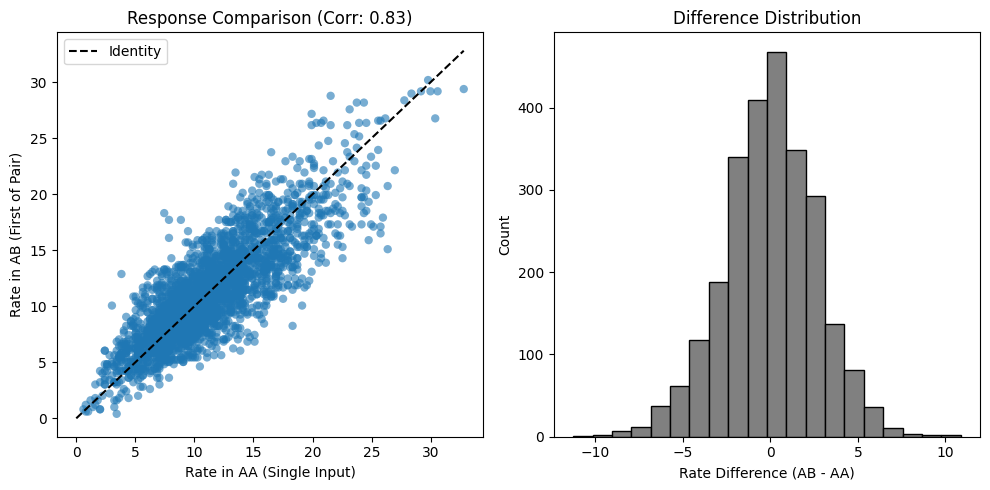

In [8]:
# ==========================================
# 1. Load Data
# ==========================================

# Dataset 1: AB (20 segments -> 2 inputs/trial)
print("Loading AB Dataset...")
ds_ab = PickledDataStore(
    load=True,
    parameters=ParameterSet({"root_directory": "SelfSustainedPushPull_test:AB1sec_12_____", "store_stimuli": False}),
    replace=False
)
dsv_ab = param_filter_query(ds_ab, st_name="PixelMovieExperanto", sheet_name="V1_Exc_L2/3")
segs_ab = dsv_ab.get_segments()

# Dataset 2: AA (10 segments -> 1 input/trial)
print("Loading AA Dataset...")
ds_aa = PickledDataStore(
    load=True,
    parameters=ParameterSet({"root_directory": "SelfSustainedPushPull_test:AA1sec_12_____", "store_stimuli": False}),
    replace=False
)
dsv_aa = param_filter_query(ds_aa, st_name="PixelMovieExperanto", sheet_name="V1_Exc_L2/3")
segs_aa = dsv_aa.get_segments()

# Dataset 3: AB (20 segments -> 2 inputs/trial)
print("Loading AB Dataset...")
ds_ab = PickledDataStore(
    load=True,
    parameters=ParameterSet({"root_directory": "AB/SelfSustainedPushPull_test:AB1_12_____", "store_stimuli": False}),
    replace=False
)
dsv_ab = param_filter_query(ds_ab, st_name="PixelMovieExperanto", sheet_name="V1_Exc_L2/3")
segs_ab1 = dsv_ab.get_segments()

# Dataset 4: AA (10 segments -> 1 input/trial)
print("Loading AA Dataset...")
ds_aa = PickledDataStore(
    load=True,
    parameters=ParameterSet({"root_directory": "AA/SelfSustainedPushPull_test:AA1_12_____", "store_stimuli": False}),
    replace=False
)
dsv_aa = param_filter_query(ds_aa, st_name="PixelMovieExperanto", sheet_name="V1_Exc_L2/3")
segs_aa1 = dsv_aa.get_segments()

# ==========================================
# 2. Select Segments by Index
# ==========================================
# AB: Take every 2nd segment (Indices 0, 2, 4... correspond to the FIRST input of the pair)
segs_A_from_AB = segs_ab[0::2] 

# AA: Take all segments (Indices 0, 1, 2... correspond to the ONLY input)
segs_A_from_AA = segs_aa[0::2]

# AB: Take every 2nd segment (Indices 0, 2, 4... correspond to the FIRST input of the pair)
segs_A_from_AB1 = segs_ab1[0::2] 

# AA: Take all segments (Indices 0, 1, 2... correspond to the ONLY input)
segs_A_from_AA1 = segs_aa1[:]

print(f"Comparing {len(segs_A_from_AB)} trials from AB vs {len(segs_A_from_AA)} trials from AA.")

# ==========================================
# 3. Calculate Mean Firing Rates (Optimized & Windowed)
# ==========================================
def calculate_rates(segments, window_start_sec=0.0, window_duration_sec=None):
    """
    Returns a dictionary {neuron_id: mean_firing_rate_hz} averaged across trials.
    Optimized with defaultdict and vectorized operations.
    If window_duration_sec is provided, only spikes within [start, start+duration] are counted.
    """
    unit_rates = defaultdict(list)
    
    for seg in tqdm(segments):
        seg_t_start = seg.t_start.rescale('s').magnitude
        seg_t_stop = seg.t_stop.rescale('s').magnitude
        
        # Determine the actual time window for counting spikes
        t_start = seg_t_start + window_start_sec
        if window_duration_sec is not None:
            t_stop = min(t_start + window_duration_sec, seg_t_stop)
        else:
            t_stop = seg_t_stop
            
        actual_duration = t_stop - t_start
        if actual_duration <= 0:
            continue
            
        for st in seg.spiketrains:
            uid = st.annotations.get('source_id', st.name)
            # Count spikes within the specific time window
            spikes = st.rescale('s').magnitude
            spike_count = np.sum((spikes >= t_start) & (spikes < t_stop))
            rate = spike_count / actual_duration
            unit_rates[uid].append(rate)
    
    # Convert to dict and compute means
    return {k: np.mean(v) for k, v in unit_rates.items()}

print("Calculating rate for AB")
rates_AB = calculate_rates(segs_A_from_AB, window_duration_sec=1.0)
print("Calculating rate for AA")
rates_AA = calculate_rates(segs_A_from_AA, window_duration_sec=1.0)
# rates_AB1 = calculate_rates(segs_A_from_AB1, window_duration_sec=1.0)
# rates_AA1 = calculate_rates(segs_A_from_AA1, window_duration_sec=1.0)


# ==========================================
# 4. Compare and Plot
# ==========================================
# Align neurons by ID
neuron_ids = sorted(rates_AA.keys())
values_AB = [rates_AB[uid] for uid in neuron_ids if uid in rates_AB]
values_AA = [rates_AA[uid] for uid in neuron_ids if uid in rates_AB]
# values_AB1 = [rates_AB1[uid] for uid in neuron_ids if uid in rates_AB1]
# values_AA1 = [rates_AA1[uid] for uid in neuron_ids if uid in rates_AB1]

# Statistics
corr = np.corrcoef(values_AA, values_AB)[0, 1]
print(f"Correlation between conditions: {corr:.4f}")

# Plot
plt.figure(figsize=(10, 5))

# Scatter
plt.subplot(1, 2, 1)
plt.scatter(values_AA, values_AB, alpha=0.6, edgecolors='none')
plt.plot([0, max(values_AA)], [0, max(values_AA)], 'k--', label="Identity")
plt.xlabel("Rate in AA (Single Input)")
plt.ylabel("Rate in AB (First of Pair)")
plt.title(f"Response Comparison (Corr: {corr:.2f})")
plt.legend()

# Histogram of differences
plt.subplot(1, 2, 2)
diffs = np.array(values_AB) - np.array(values_AA)
plt.hist(diffs, bins=20, color='gray', edgecolor='black')
plt.xlabel("Rate Difference (AB - AA)")
plt.ylabel("Count")
plt.title("Difference Distribution")

plt.tight_layout()
plt.savefig("results/response_comparison.png")
plt.show()

Correlation between conditions: 0.8282


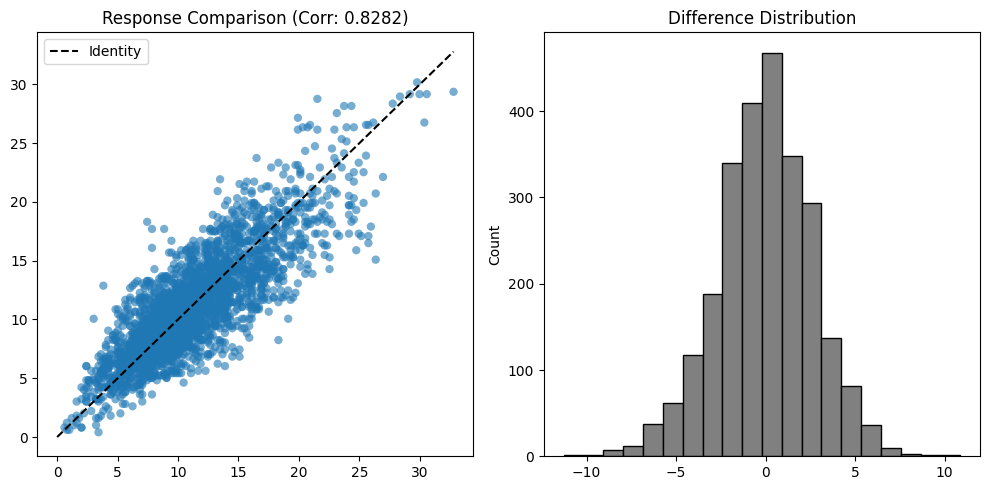

0.8281765064596947

In [9]:
# Statistics
def plot_corr(series1, series2, save_path):
    corr = np.corrcoef(series1, series2)[0, 1]
    print(f"Correlation between conditions: {corr:.4f}")
    
    # Plot
    plt.figure(figsize=(10, 5))
    
    # Scatter
    plt.subplot(1, 2, 1)
    plt.scatter(series1, series2, alpha=0.6, edgecolors='none')
    plt.plot([0, max(series1)], [0, max(series1)], 'k--', label="Identity")
    # plt.xlabel("Rate in AA (Single Input)")
    # plt.ylabel("Rate in AA1 (First of Pair)")
    plt.title(f"Response Comparison (Corr: {corr:.4f})")
    plt.legend()
    
    # Histogram of differences
    plt.subplot(1, 2, 2)
    diffs = np.array(series2) - np.array(series1)
    plt.hist(diffs, bins=20, color='gray', edgecolor='black')
    # plt.xlabel("Rate Difference (AA1 - AA)")
    plt.ylabel("Count")
    plt.title("Difference Distribution")
    
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()
    return corr
    plt.close('all')

plot_corr(values_AA, values_AB, "results/response_comparison.png")

Loading AA Dataset...
5
5
Correlation between conditions: 0.7027


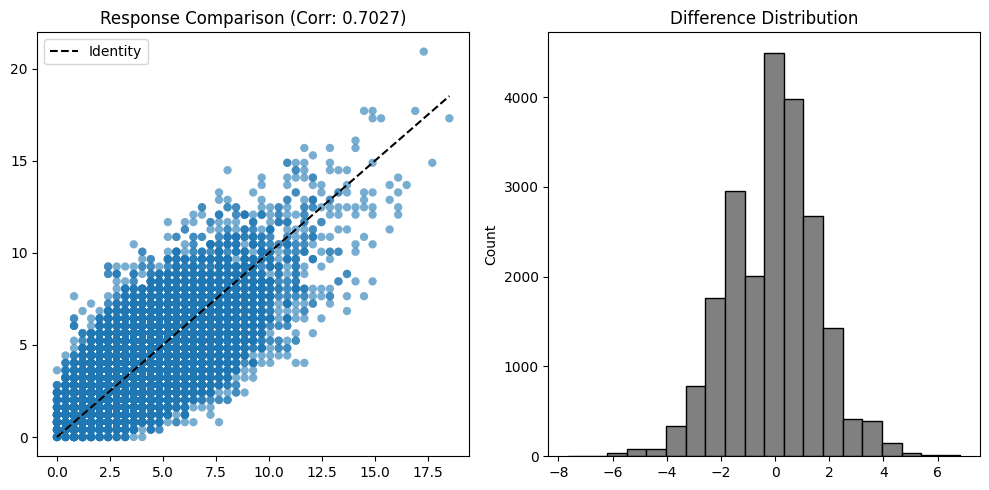

0.7026836907726883

In [ ]:
print("Loading AA Dataset...")
ds_aa = PickledDataStore(
    load=True,
    parameters=ParameterSet({"root_directory": "SelfSustainedPushPull_test:midAA_null35_12_____", "store_stimuli": False}),
    replace=False
)
dsv_aa = param_filter_query(ds_aa, st_name="PixelMovieExperanto", sheet_name="V1_Exc_L2/3")
segs_aa = dsv_aa.get_segments()

# Parse stimulus info once and sort
parsed_aa = [(seg, parse_stimulus(seg.annotations['stimulus'])) for seg in segs_aa]
parsed_aa.sort(key=lambda x: x[1]['trial'])

# AA: Take specific segments based on trial interleaving
trials = 5
first_A_from_AA = [seg for i, (seg, _) in enumerate(parsed_aa) if i % 2 == 0 and i < trials * 2]
first_A1_from_AA = [seg for i, (seg, _) in enumerate(parsed_aa) if i % 2 == 1 and i < trials * 2 + 1]

print(len(first_A_from_AA))
rates_A = calculate_rates(first_A_from_AA, window_duration_sec=1.0)
neuron_ids = sorted(rates_A.keys())
values_A = [rates_A[uid] for uid in neuron_ids if uid in rates_A]

print(len(first_A1_from_AA))
rates_A1 = calculate_rates(first_A1_from_AA, window_duration_sec=1.0)
values_A1 = [rates_A1[uid] for uid in neuron_ids if uid in rates_A1]

plot_corr(values_A, values_A1, f"results/mid_response_comparison_interleafA_0sec_trials_{trials}.png")

Movie A identified as: 00005.npy


100%|█████████████████████████████████████████████████████████████████████████████████████| 10/10 [08:19<00:00, 49.98s/it]


Length of intersection of neuron ids: 21642
Length of union - intersection of neuron ids: 0
results/response_comparison_midAA_null35_midAB_null35.png
Correlation between conditions: 0.8607


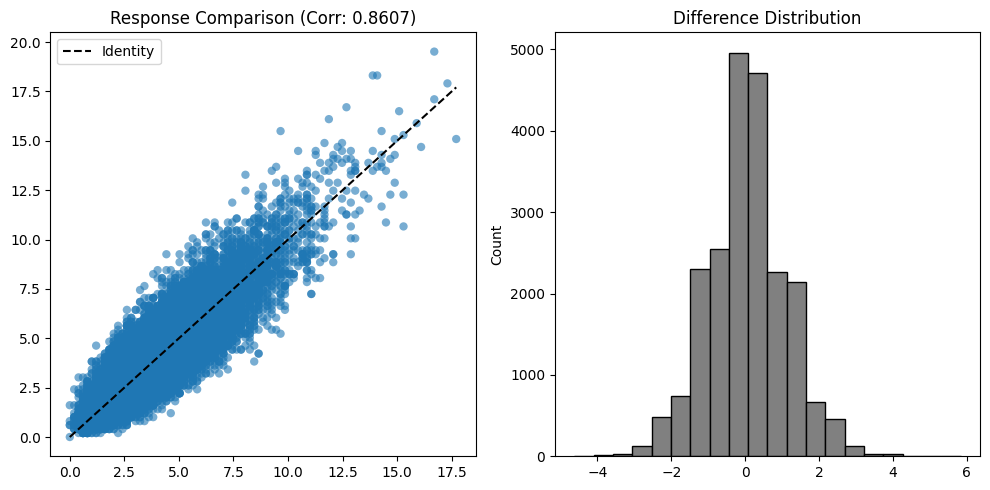

Movie A identified as: 00005.npy


100%|█████████████████████████████████████████████████████████████████████████████████████| 10/10 [08:22<00:00, 50.23s/it]


Length of intersection of neuron ids: 21642
Length of union - intersection of neuron ids: 0
results/response_comparison_midAA_null35_midAB_null1035.png
Correlation between conditions: 0.8278


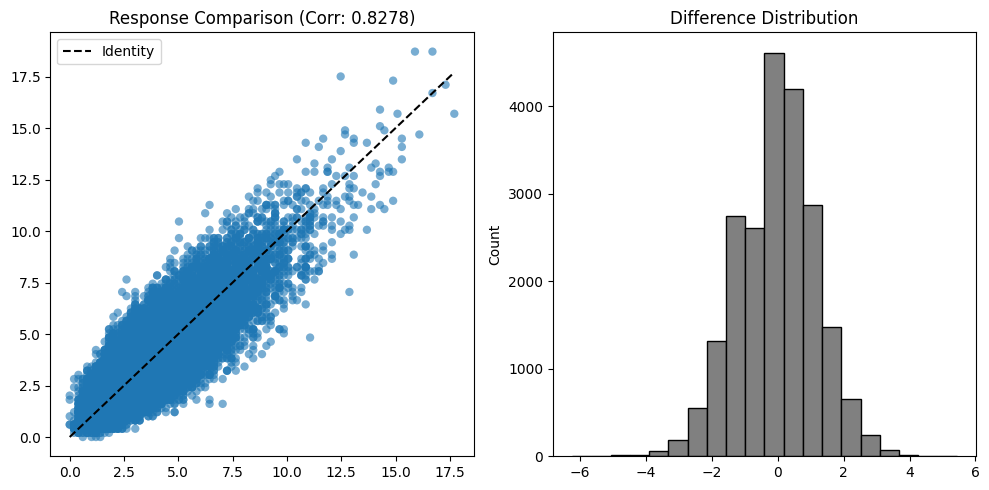

Movie A identified as: 00005.npy


100%|█████████████████████████████████████████████████████████████████████████████████████| 10/10 [08:12<00:00, 49.24s/it]


Length of intersection of neuron ids: 21642
Length of union - intersection of neuron ids: 0
results/response_comparison_midAA_null35_midAB_null9035.png
Correlation between conditions: 0.8311


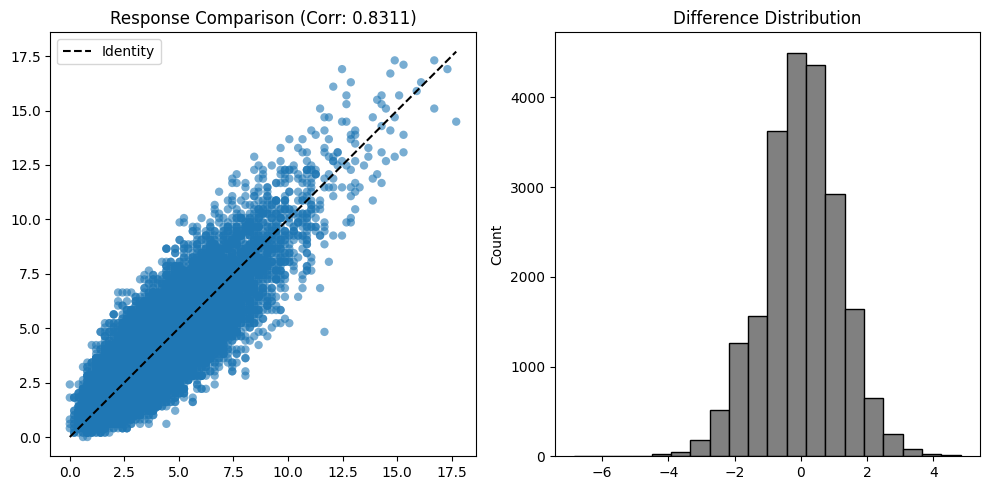

Movie A identified as: 00005.npy


100%|█████████████████████████████████████████████████████████████████████████████████████| 10/10 [08:09<00:00, 48.95s/it]


Length of intersection of neuron ids: 21642
Length of union - intersection of neuron ids: 0
results/response_comparison_midAA_null35_midAB_1sec.png
Correlation between conditions: 0.8356


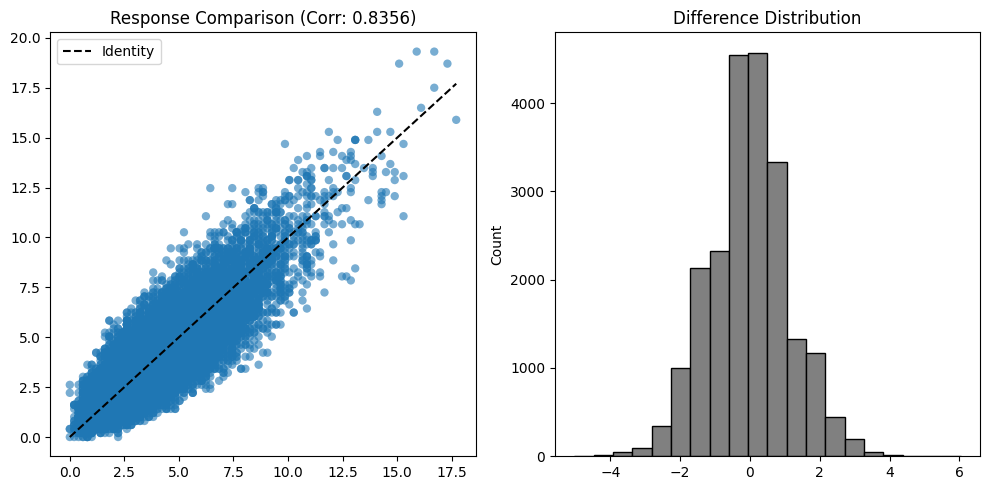

Movie A identified as: 00005.npy


100%|█████████████████████████████████████████████████████████████████████████████████████| 10/10 [08:23<00:00, 50.31s/it]


Length of intersection of neuron ids: 21642
Length of union - intersection of neuron ids: 0
results/response_comparison_midAA_null35_midAB_9sec.png
Correlation between conditions: 0.8290


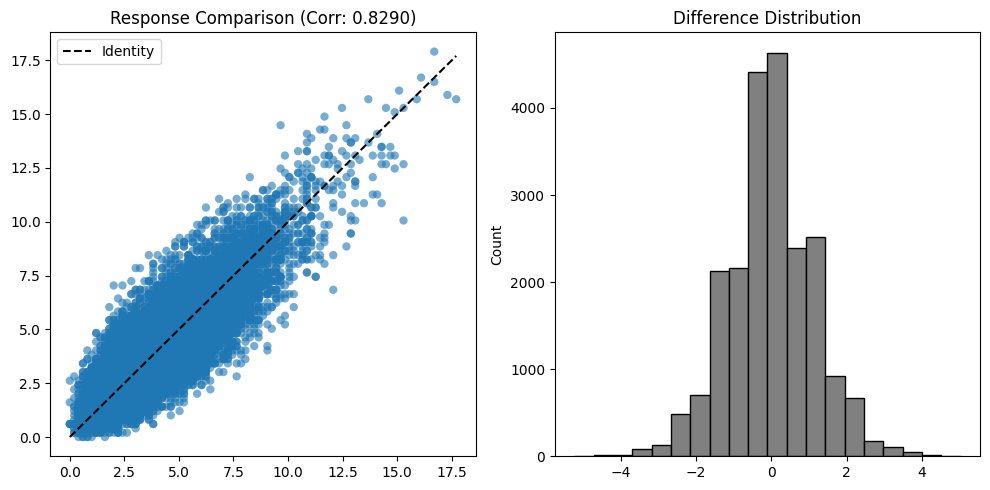

Movie A identified as: 00005.npy


100%|█████████████████████████████████████████████████████████████████████████████████████| 10/10 [06:57<00:00, 41.78s/it]


Length of intersection of neuron ids: 21642
Length of union - intersection of neuron ids: 0
results/response_comparison_midAA_null1035_midAB_null35.png
Correlation between conditions: 0.8293


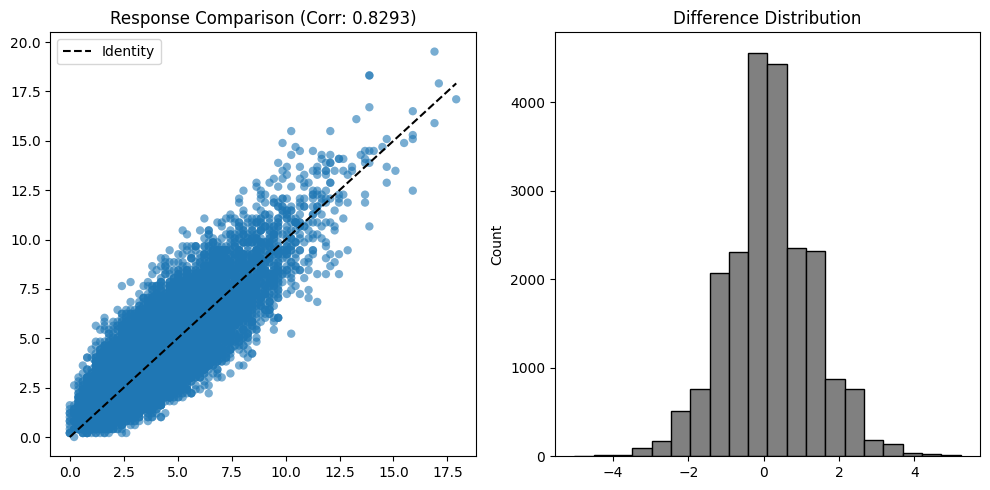

Movie A identified as: 00005.npy


100%|█████████████████████████████████████████████████████████████████████████████████████| 10/10 [07:02<00:00, 42.24s/it]


Length of intersection of neuron ids: 21642
Length of union - intersection of neuron ids: 0
results/response_comparison_midAA_null1035_midAB_null1035.png
Correlation between conditions: 0.8679


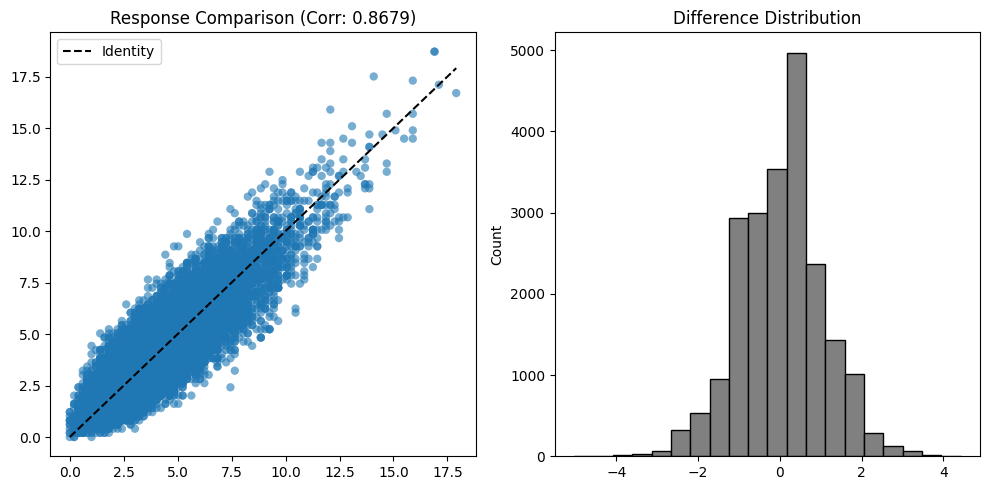

Movie A identified as: 00005.npy


100%|█████████████████████████████████████████████████████████████████████████████████████| 10/10 [07:01<00:00, 42.19s/it]


Length of intersection of neuron ids: 21642
Length of union - intersection of neuron ids: 0
results/response_comparison_midAA_null1035_midAB_null9035.png
Correlation between conditions: 0.8372


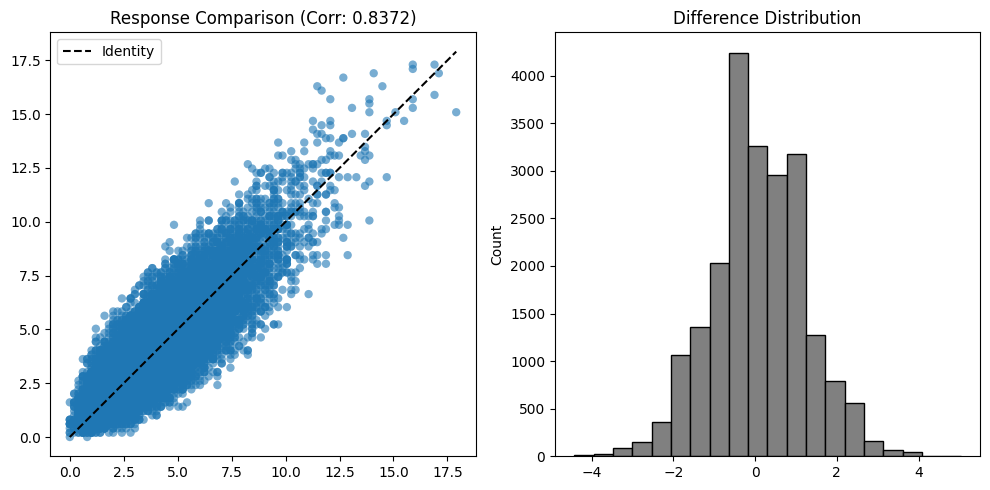

Movie A identified as: 00005.npy


100%|█████████████████████████████████████████████████████████████████████████████████████| 10/10 [07:04<00:00, 42.40s/it]


Length of intersection of neuron ids: 21642
Length of union - intersection of neuron ids: 0
results/response_comparison_midAA_null1035_midAB_1sec.png
Correlation between conditions: 0.8396


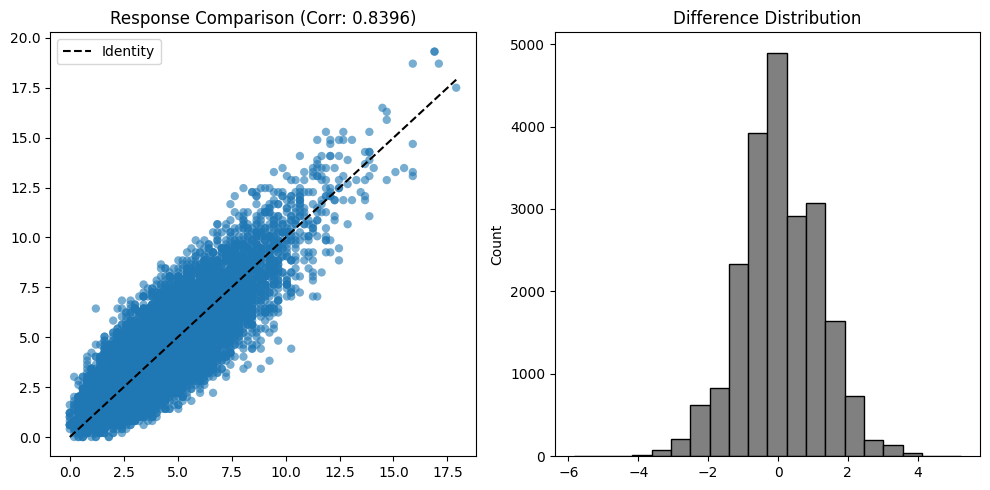

Movie A identified as: 00005.npy


100%|█████████████████████████████████████████████████████████████████████████████████████| 10/10 [07:03<00:00, 42.34s/it]


Length of intersection of neuron ids: 21642
Length of union - intersection of neuron ids: 0
results/response_comparison_midAA_null1035_midAB_9sec.png
Correlation between conditions: 0.8339


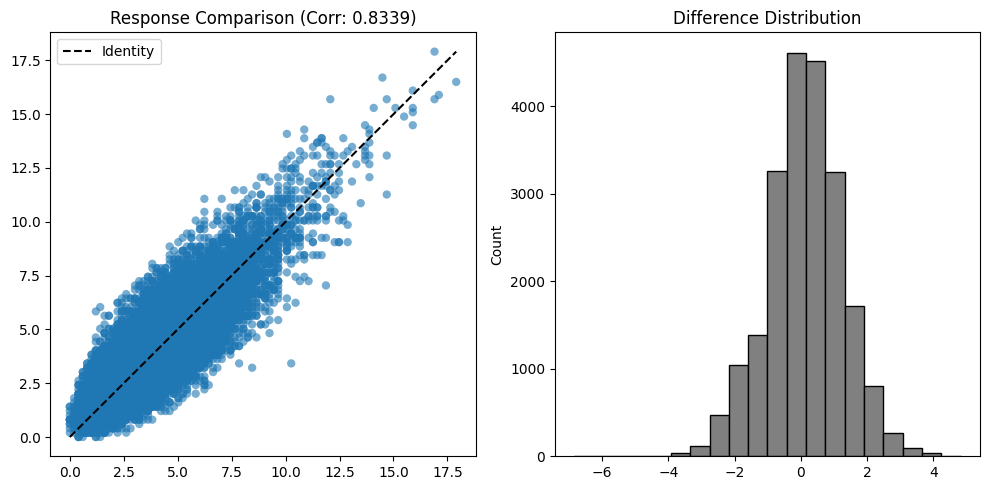

Movie A identified as: 00005.npy


100%|█████████████████████████████████████████████████████████████████████████████████████| 10/10 [07:00<00:00, 42.08s/it]


Length of intersection of neuron ids: 21642
Length of union - intersection of neuron ids: 0
results/response_comparison_midAA_null9035_midAB_null35.png
Correlation between conditions: 0.8311


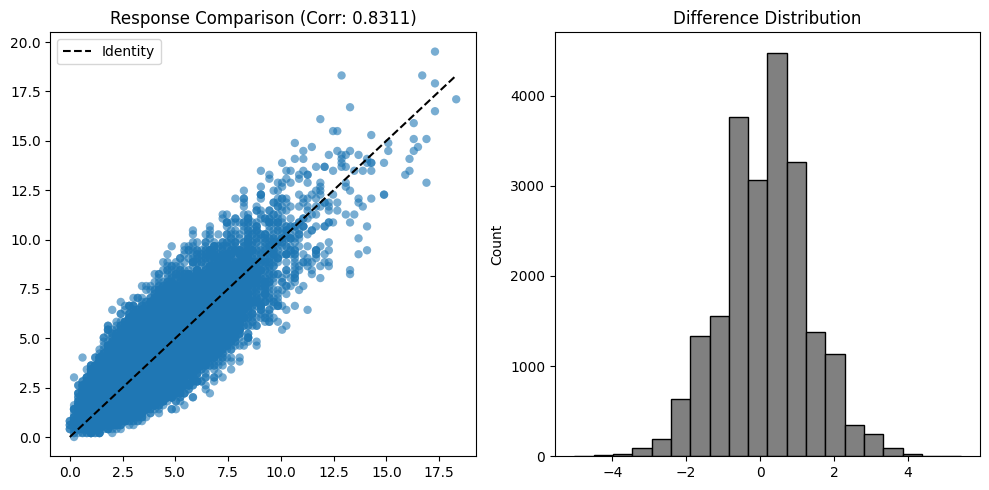

Movie A identified as: 00005.npy


100%|█████████████████████████████████████████████████████████████████████████████████████| 10/10 [07:05<00:00, 42.53s/it]


Length of intersection of neuron ids: 21642
Length of union - intersection of neuron ids: 0
results/response_comparison_midAA_null9035_midAB_null1035.png
Correlation between conditions: 0.8277


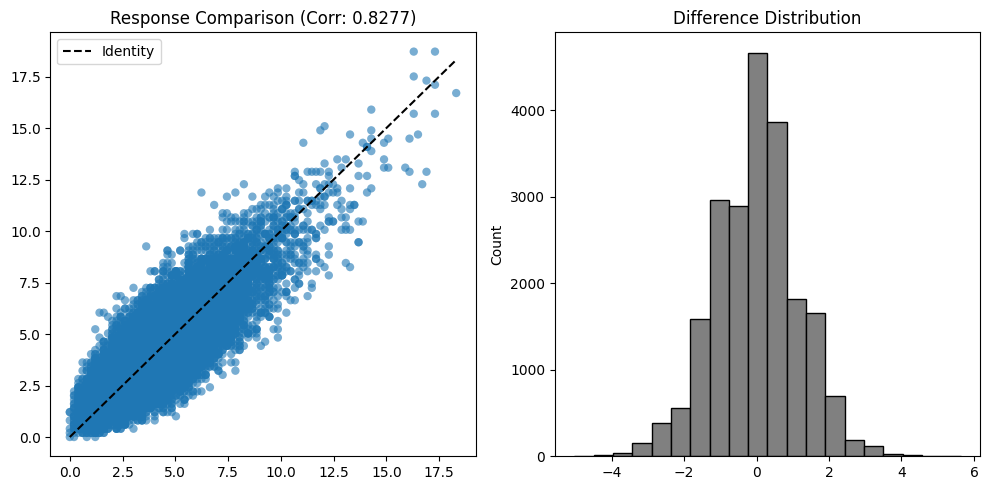

Movie A identified as: 00005.npy


100%|█████████████████████████████████████████████████████████████████████████████████████| 10/10 [07:02<00:00, 42.26s/it]


Length of intersection of neuron ids: 21642
Length of union - intersection of neuron ids: 0
results/response_comparison_midAA_null9035_midAB_null9035.png
Correlation between conditions: 0.8694


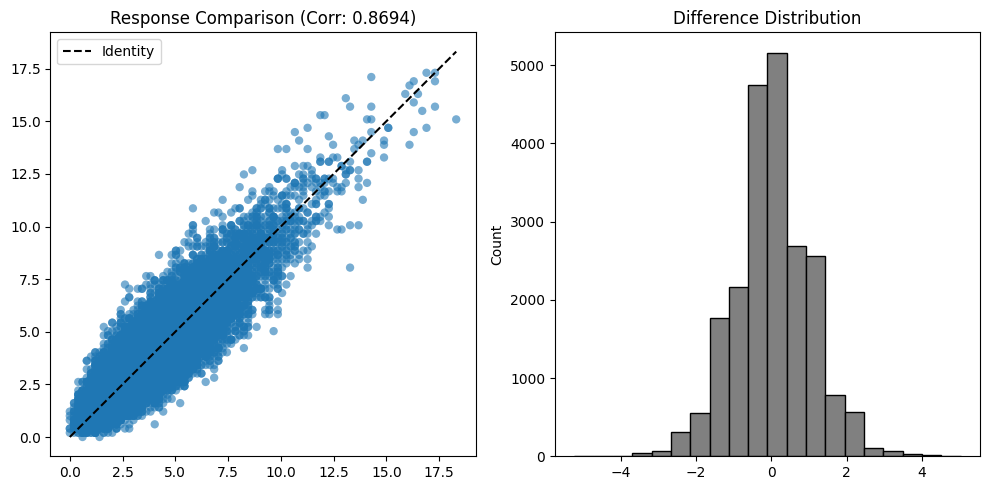

Movie A identified as: 00005.npy


100%|█████████████████████████████████████████████████████████████████████████████████████| 10/10 [07:17<00:00, 43.75s/it]


Length of intersection of neuron ids: 21642
Length of union - intersection of neuron ids: 0
results/response_comparison_midAA_null9035_midAB_1sec.png
Correlation between conditions: 0.8346


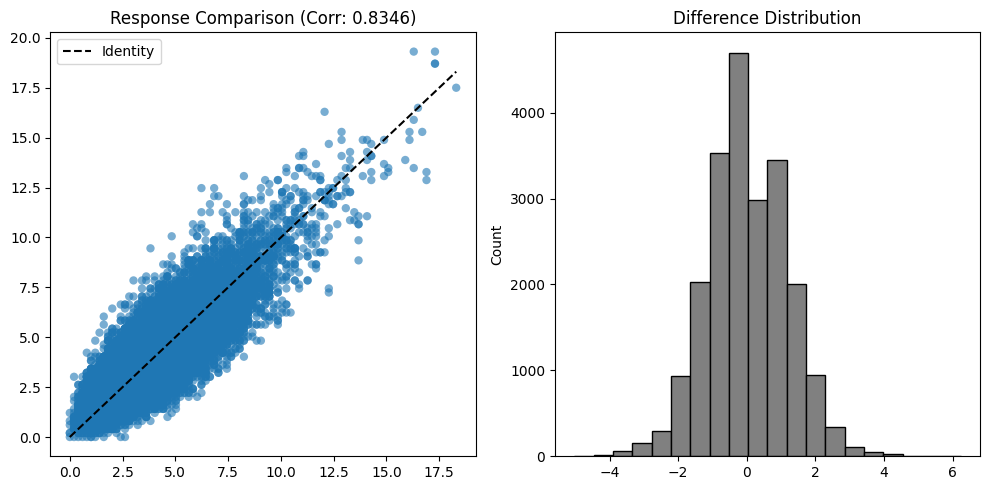

Movie A identified as: 00005.npy


100%|█████████████████████████████████████████████████████████████████████████████████████| 10/10 [06:57<00:00, 41.71s/it]


Length of intersection of neuron ids: 21642
Length of union - intersection of neuron ids: 0
results/response_comparison_midAA_null9035_midAB_9sec.png
Correlation between conditions: 0.8337


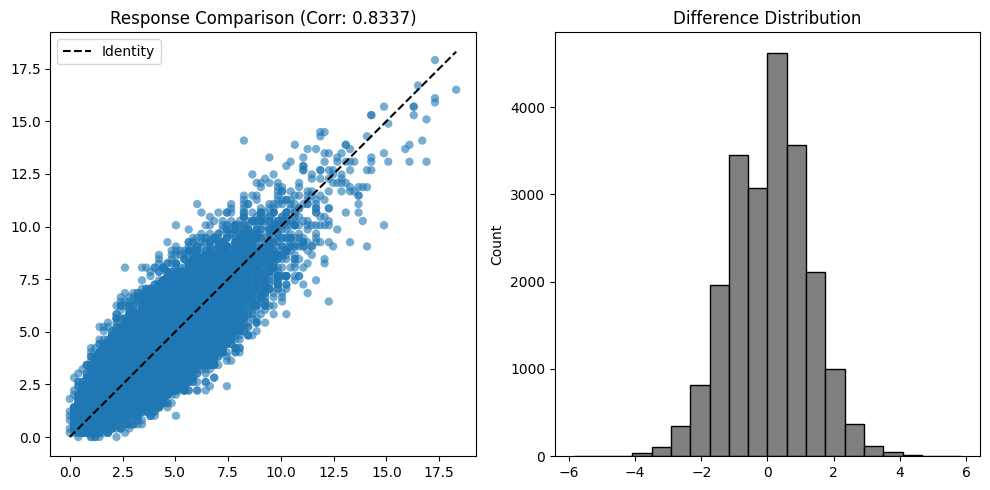

Movie A identified as: 00005.npy


100%|█████████████████████████████████████████████████████████████████████████████████████| 10/10 [07:02<00:00, 42.22s/it]


Length of intersection of neuron ids: 21642
Length of union - intersection of neuron ids: 0
results/response_comparison_midAA_1sec_midAB_null35.png
Correlation between conditions: 0.8333


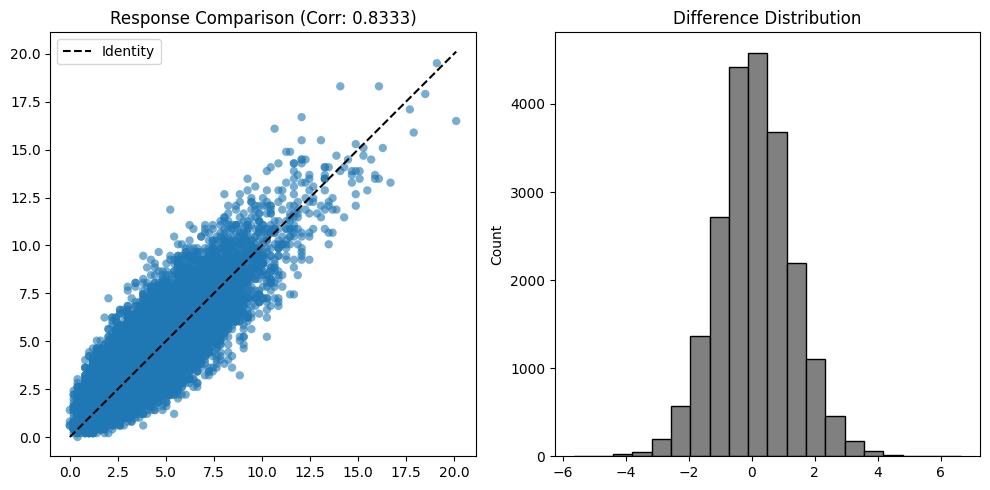

Movie A identified as: 00005.npy


100%|█████████████████████████████████████████████████████████████████████████████████████| 10/10 [06:57<00:00, 41.79s/it]


Length of intersection of neuron ids: 21642
Length of union - intersection of neuron ids: 0
results/response_comparison_midAA_1sec_midAB_null1035.png
Correlation between conditions: 0.8402


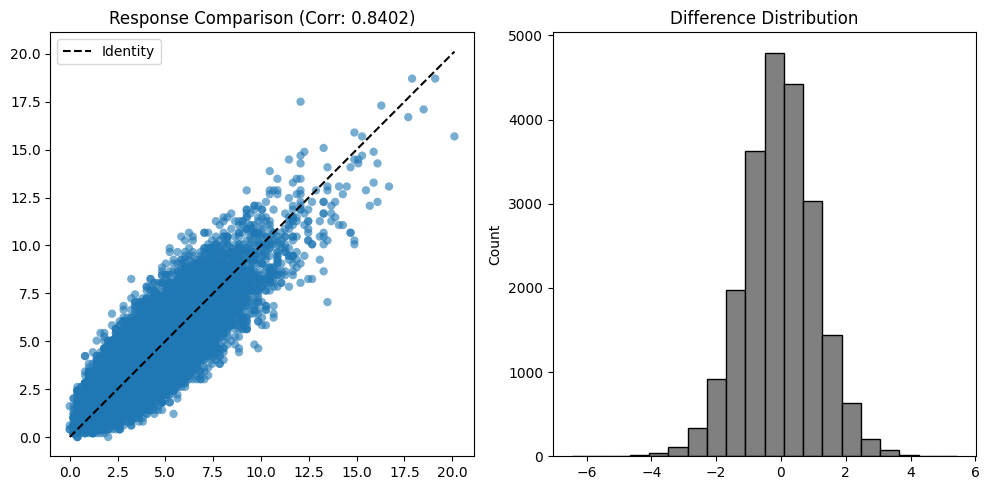

Movie A identified as: 00005.npy


100%|█████████████████████████████████████████████████████████████████████████████████████| 10/10 [06:42<00:00, 40.23s/it]


Length of intersection of neuron ids: 21642
Length of union - intersection of neuron ids: 0
results/response_comparison_midAA_1sec_midAB_null9035.png
Correlation between conditions: 0.8297


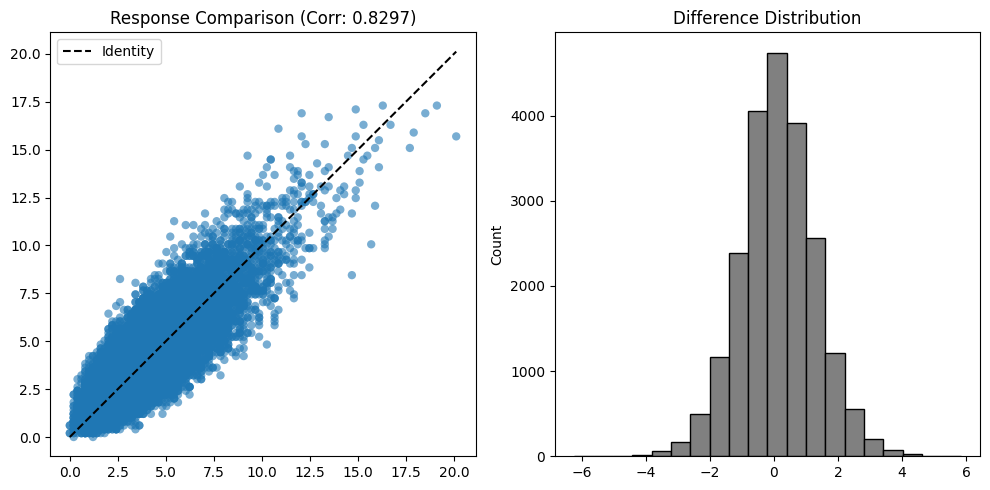

Movie A identified as: 00005.npy


100%|█████████████████████████████████████████████████████████████████████████████████████| 10/10 [06:57<00:00, 41.73s/it]


Length of intersection of neuron ids: 21642
Length of union - intersection of neuron ids: 0
results/response_comparison_midAA_1sec_midAB_1sec.png
Correlation between conditions: 0.8578


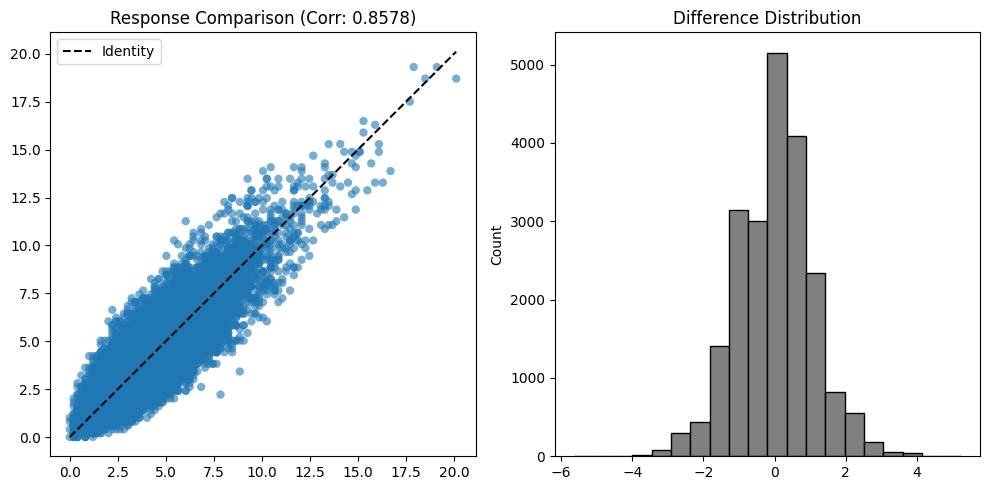

Movie A identified as: 00005.npy


100%|█████████████████████████████████████████████████████████████████████████████████████| 10/10 [06:55<00:00, 41.53s/it]


Length of intersection of neuron ids: 21642
Length of union - intersection of neuron ids: 0
results/response_comparison_midAA_1sec_midAB_9sec.png
Correlation between conditions: 0.8375


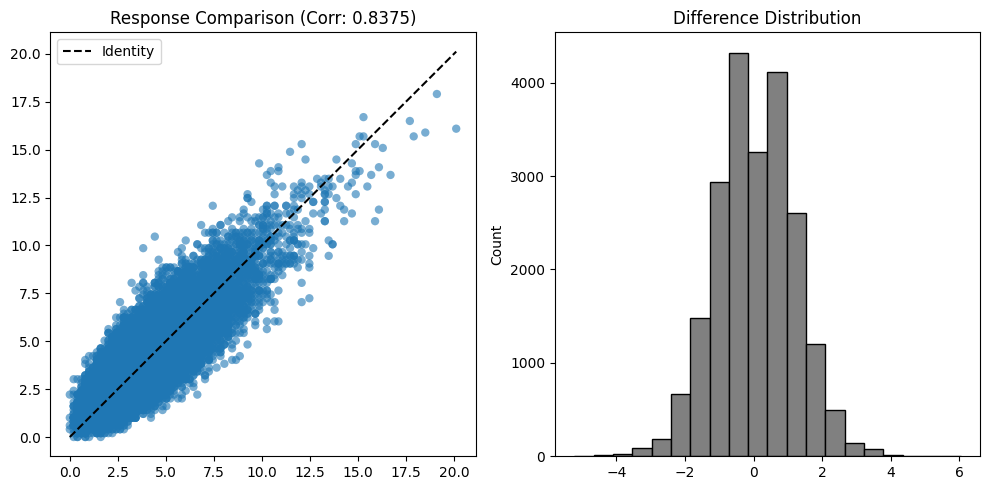

Movie A identified as: 00005.npy


100%|█████████████████████████████████████████████████████████████████████████████████████| 10/10 [06:43<00:00, 40.32s/it]


Length of intersection of neuron ids: 21642
Length of union - intersection of neuron ids: 0
results/response_comparison_midAA_9sec_midAB_null35.png
Correlation between conditions: 0.8311


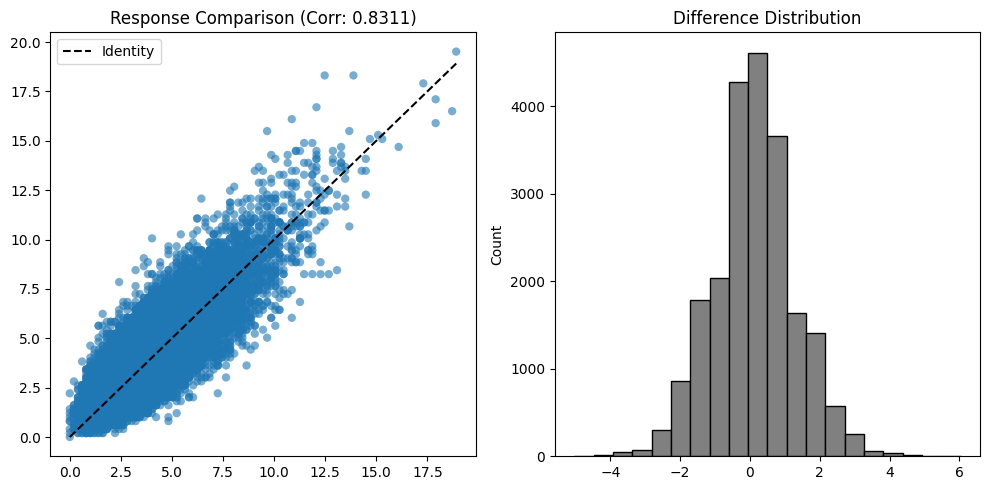

Movie A identified as: 00005.npy


100%|█████████████████████████████████████████████████████████████████████████████████████| 10/10 [06:51<00:00, 41.14s/it]


Length of intersection of neuron ids: 21642
Length of union - intersection of neuron ids: 0
results/response_comparison_midAA_9sec_midAB_null1035.png
Correlation between conditions: 0.8343


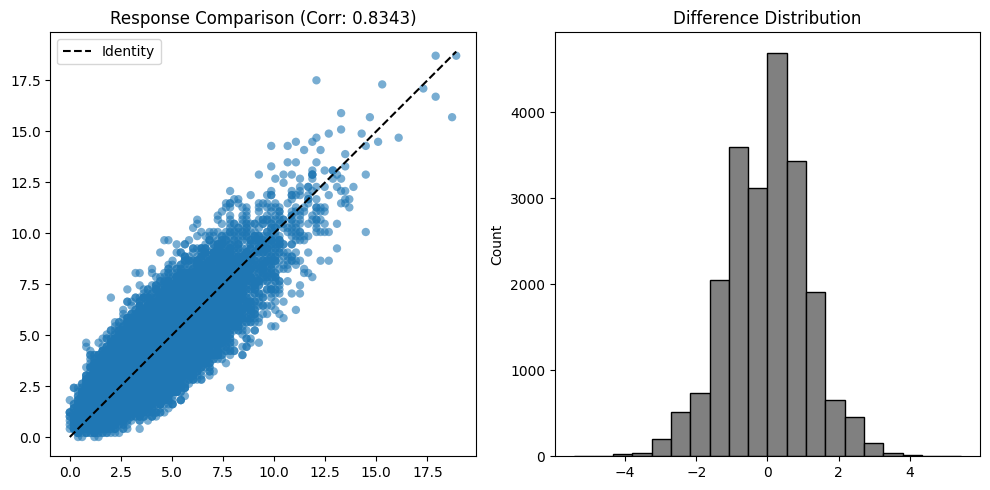

Movie A identified as: 00005.npy


100%|█████████████████████████████████████████████████████████████████████████████████████| 10/10 [06:56<00:00, 41.64s/it]


Length of intersection of neuron ids: 21642
Length of union - intersection of neuron ids: 0
results/response_comparison_midAA_9sec_midAB_null9035.png
Correlation between conditions: 0.8262


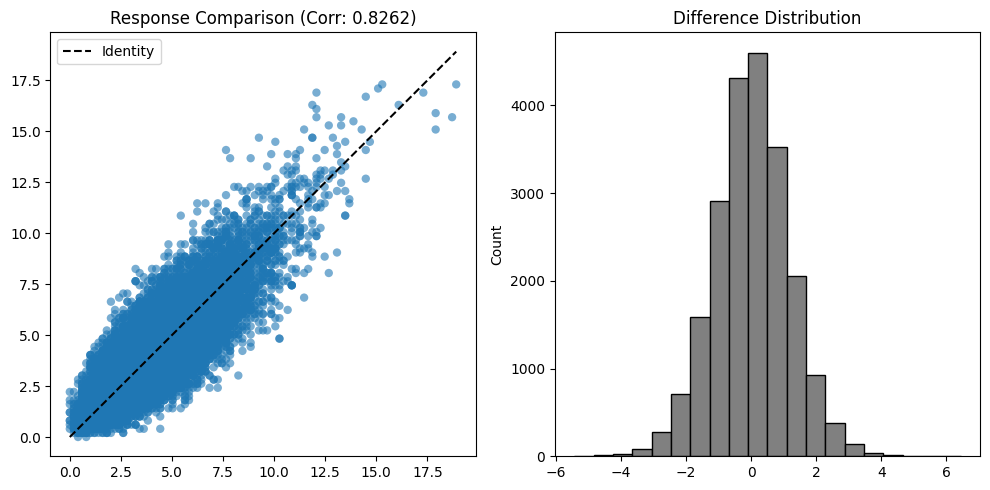

Movie A identified as: 00005.npy


100%|█████████████████████████████████████████████████████████████████████████████████████| 10/10 [06:50<00:00, 41.07s/it]


Length of intersection of neuron ids: 21642
Length of union - intersection of neuron ids: 0
results/response_comparison_midAA_9sec_midAB_1sec.png
Correlation between conditions: 0.8351


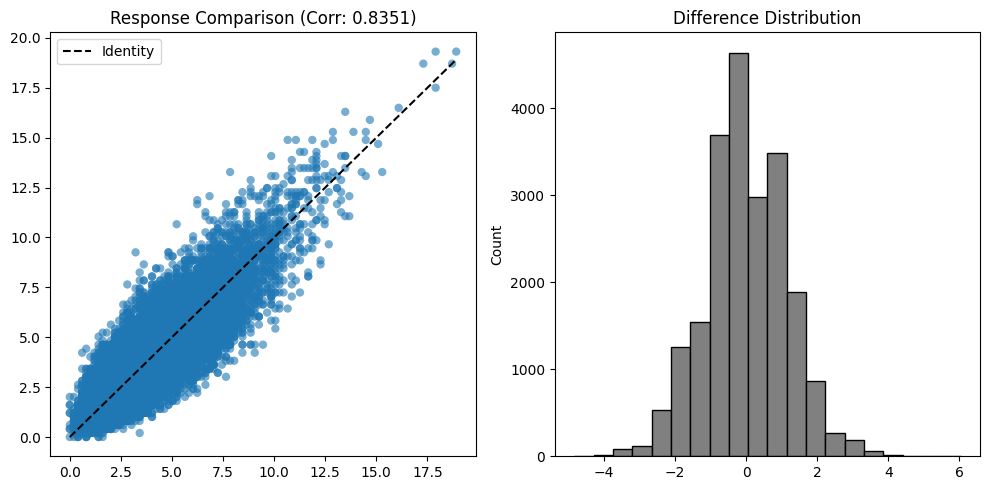

Movie A identified as: 00005.npy


100%|█████████████████████████████████████████████████████████████████████████████████████| 10/10 [06:52<00:00, 41.23s/it]


Length of intersection of neuron ids: 21642
Length of union - intersection of neuron ids: 0
results/response_comparison_midAA_9sec_midAB_9sec.png
Correlation between conditions: 0.8495


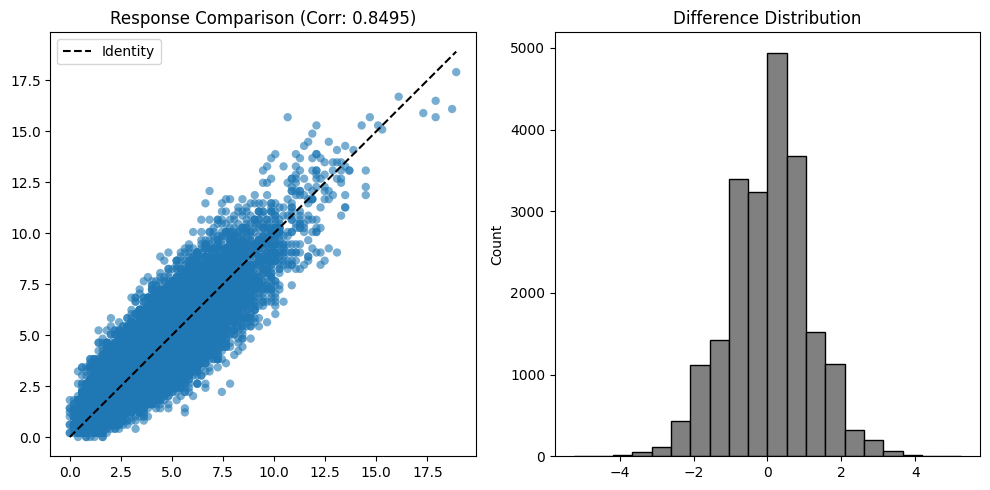

In [5]:
AA_list = ["midAA_null35", "midAA_null1035", "midAA_null9035", "midAA_1sec", "midAA_9sec"]
AB_list = ["midAB_null35", "midAB_null1035", "midAB_null9035", "midAB_1sec", "midAB_9sec"]
# AA_list = ["AA1sec", "AA9sec"]
# AB_list = ["AB1sec", "AB9sec"]
# AB_list = ["AB_noblank", "AB_null150", "AB_null300", "AB_null535"]

data = {y:{x:0 for x in AA_list} for y in AB_list}

# Pre-load all datasets once
datasets = {}
for aa_name in AA_list:
    datasets[aa_name] = PickledDataStore(
        load=True,
        parameters=ParameterSet({"root_directory": f"SelfSustainedPushPull_test:{aa_name}_12_____", "store_stimuli": False}),
        replace=False
    )
    
for ab_name in AB_list:
    datasets[ab_name] = PickledDataStore(
        load=True,
        parameters=ParameterSet({"root_directory": f"SelfSustainedPushPull_test:{ab_name}_12_____", "store_stimuli": False}),
        replace=False
    )

# Pre-parse and cache stimulus information for all segments
segment_cache = {}

for dataset_name, ds in datasets.items():
    dsv = param_filter_query(ds, st_name="PixelMovieExperanto", sheet_name="V1_Exc_L2/3")
    segs = dsv.get_segments()
    
    # Pre-parse stimulus info for faster access
    parsed_stimuli = []
    for seg in segs:
        stim_dict = parse_stimulus(seg.annotations['stimulus'])
        parsed_stimuli.append((seg, stim_dict))
    
    # Sort once
    parsed_stimuli.sort(key=lambda x: x[1]['trial'])
    segment_cache[dataset_name] = parsed_stimuli

# Now run comparisons with cached data
for i, AA in enumerate(AA_list):
    for j, AB in enumerate(AB_list):
        parsed_aa = segment_cache[AA]
        parsed_ab = segment_cache[AB]
        
        # Get the A movie name from first AA segment
        movie_A_name = parsed_aa[0][1]['movie_name']
        print(f"Movie A identified as: {movie_A_name}")
        
        # Filter AB segments to only include the A movie (already sorted)
        A_from_AB = [seg for seg, stim_dict in parsed_ab if stim_dict['movie_name'] == movie_A_name]
        
        # Take every other segment from AA
        alt_A_from_AA = [seg for seg, _ in parsed_aa[0::2]]
        
        # Sanity check
        movie_names = set(stim_dict['movie_name'] for _, stim_dict in parsed_ab if stim_dict['movie_name'] == movie_A_name)
        assert len(movie_names) == 1, f"Expected 1 movie type in the slice, but found: {movie_names}"
        assert len(A_from_AB) == len(alt_A_from_AA), f"Expected number of trials to be same, but got {len(A_from_AB)} and {len(alt_A_from_AA)}"

        # Consistent rate calculation within a 1s window (ignoring variable 'null' time)
        rates_A = calculate_rates(alt_A_from_AA, window_duration_sec=1.0)
        rates_AB = calculate_rates(A_from_AB, window_duration_sec=1.0)
        
        common_ids = sorted(set(rates_A.keys()) & set(rates_AB.keys()))
        print("Length of intersection of neuron ids:", len(common_ids))
        print("Length of union - intersection of neuron ids:", len(set(rates_A.keys()) ^ set(rates_AB.keys())))
        
        values_A = [rates_A[uid] for uid in common_ids]
        values_AB = [rates_AB[uid] for uid in common_ids]

        print(f"results/response_comparison_{AA}_{AB}.png")
        corr = plot_corr(values_A, values_AB, f"results/AB_time_comp_correct/response_comparison_{AA}_{AB}.png")
        data[AB][AA] = corr
        
with open('corr.json', 'w') as f:
    json.dump(data, f, indent=2)

100%|████████████████████████████████████████████████████████████████████████████████████| 10/10 [13:07<00:00, 78.71s/it]


Length of intersection of neuron ids: 21642
Length of union - intersection of neuron ids: 0
results/response_comparison_midAA_null35_midAA_null35.png
Correlation between conditions: 0.8316


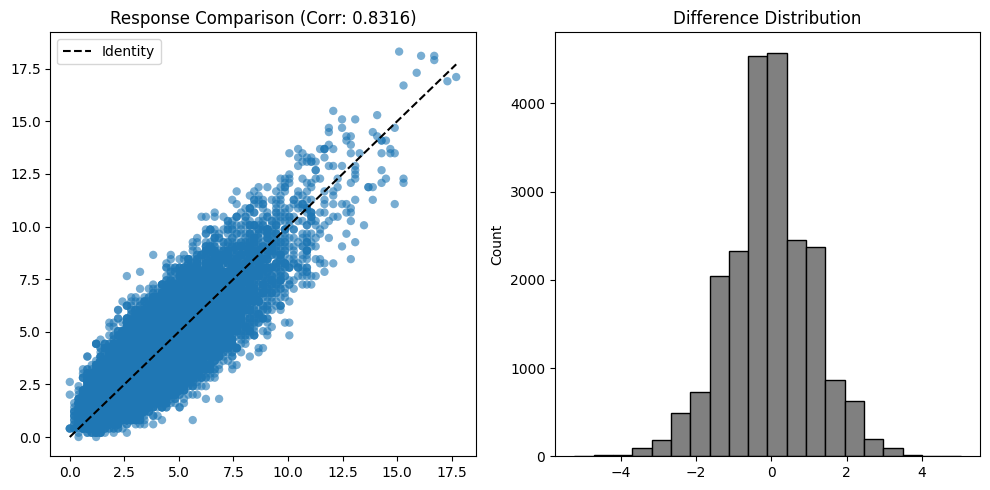

100%|████████████████████████████████████████████████████████████████████████████████████| 10/10 [12:04<00:00, 72.49s/it]


Length of intersection of neuron ids: 21642
Length of union - intersection of neuron ids: 0
results/response_comparison_midAA_null35_midAA_null1035.png
Correlation between conditions: 0.8213


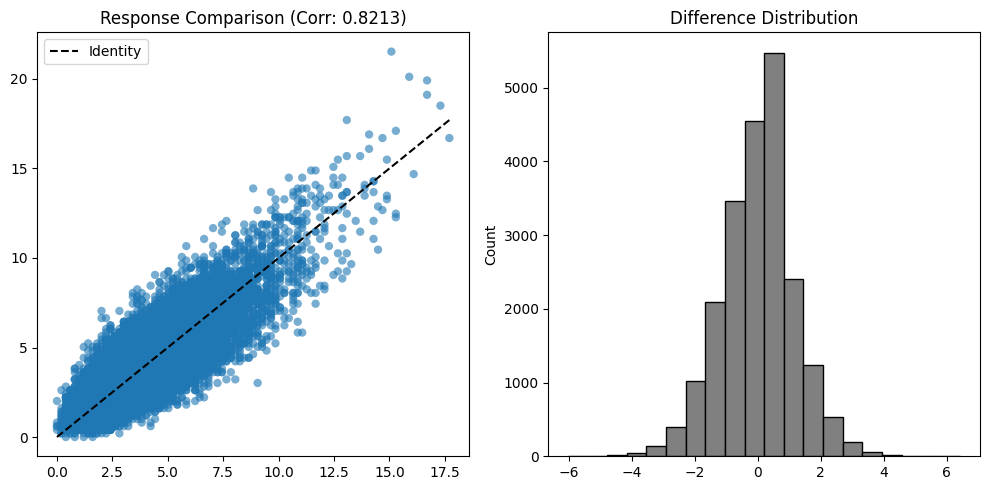

100%|████████████████████████████████████████████████████████████████████████████████████| 10/10 [12:02<00:00, 72.26s/it]


Length of intersection of neuron ids: 21642
Length of union - intersection of neuron ids: 0
results/response_comparison_midAA_null35_midAA_null9035.png
Correlation between conditions: 0.8285


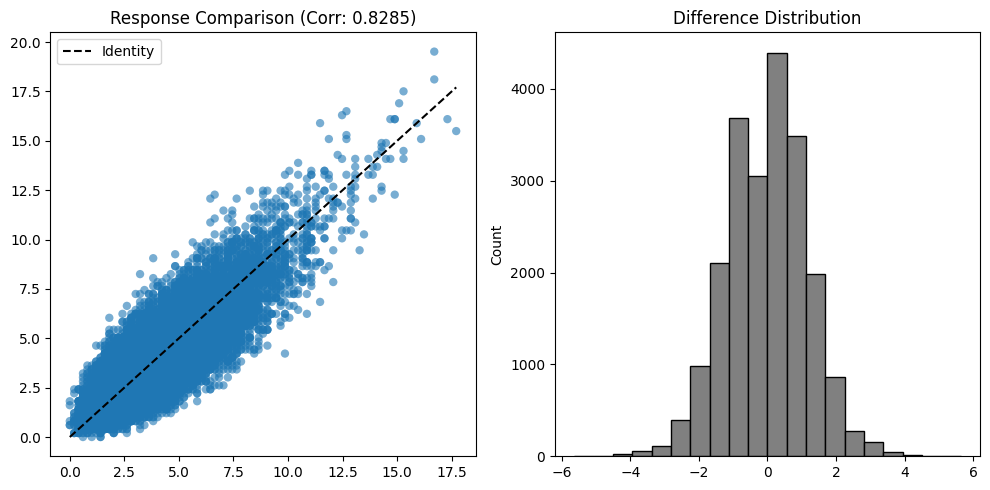

100%|████████████████████████████████████████████████████████████████████████████████████| 10/10 [12:05<00:00, 72.60s/it]


Length of intersection of neuron ids: 21642
Length of union - intersection of neuron ids: 0
results/response_comparison_midAA_null35_midAA_1sec.png
Correlation between conditions: 0.8350


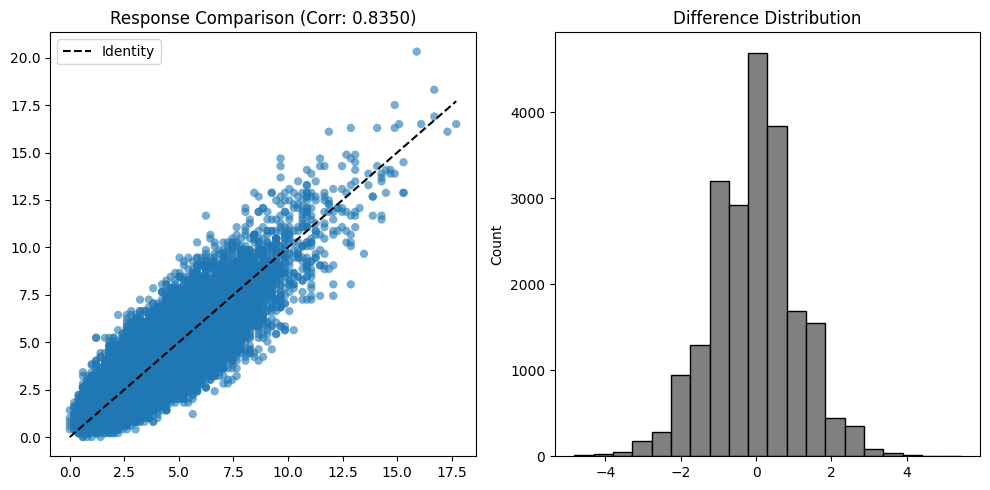

100%|████████████████████████████████████████████████████████████████████████████████████| 10/10 [11:58<00:00, 71.82s/it]


Length of intersection of neuron ids: 21642
Length of union - intersection of neuron ids: 0
results/response_comparison_midAA_null35_midAA_9sec.png
Correlation between conditions: 0.8205


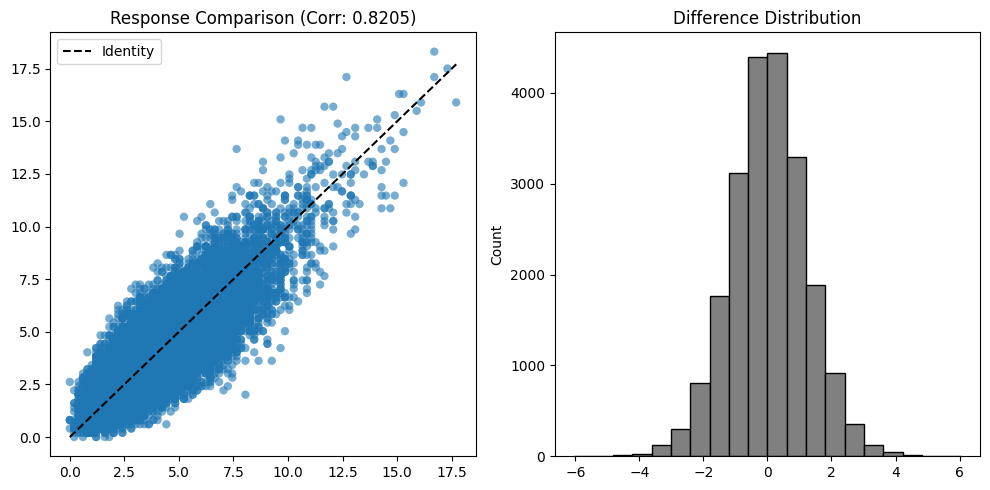

100%|████████████████████████████████████████████████████████████████████████████████████| 10/10 [10:23<00:00, 62.36s/it]


Length of intersection of neuron ids: 21642
Length of union - intersection of neuron ids: 0
results/response_comparison_midAA_null1035_midAA_null35.png
Correlation between conditions: 0.8319


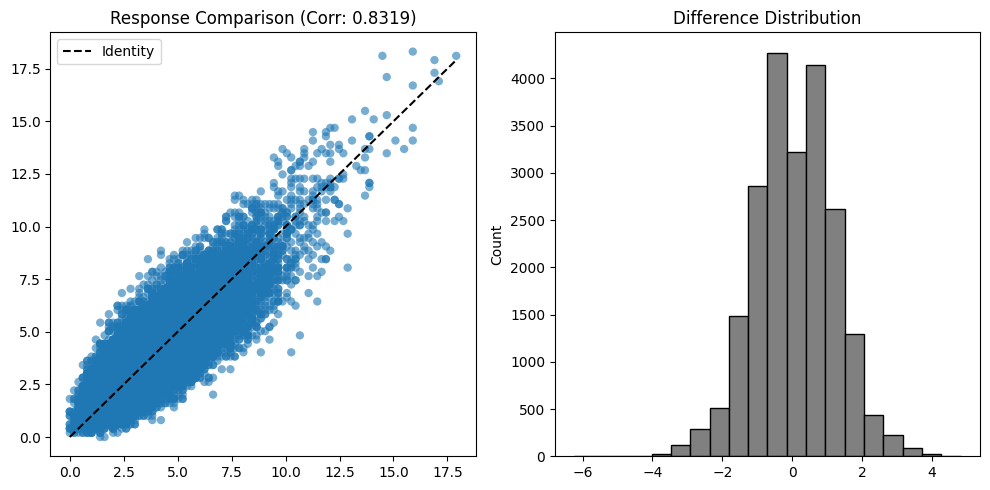

100%|████████████████████████████████████████████████████████████████████████████████████| 10/10 [10:22<00:00, 62.23s/it]


Length of intersection of neuron ids: 21642
Length of union - intersection of neuron ids: 0
results/response_comparison_midAA_null1035_midAA_null1035.png
Correlation between conditions: 0.8260


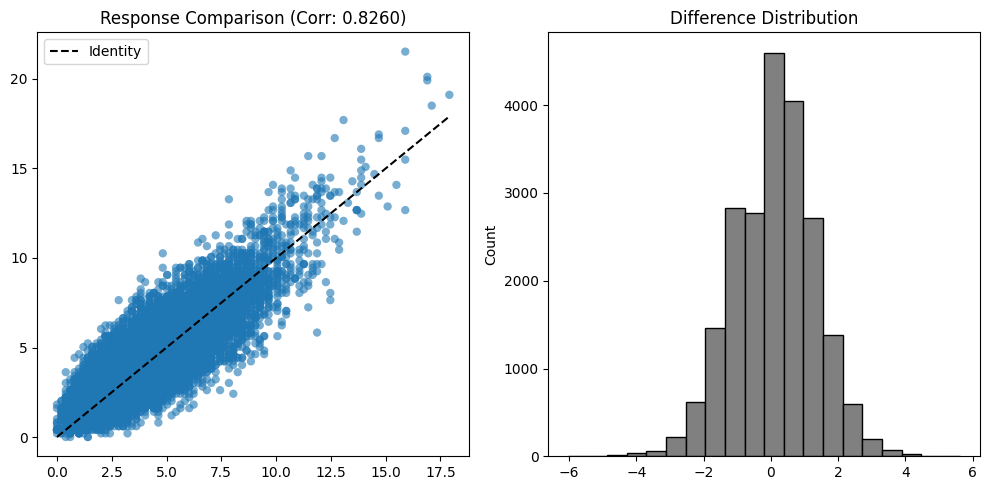

 20%|█████████████████                                                                    | 2/10 [02:32<10:08, 76.09s/it]


KeyboardInterrupt: 

In [10]:
AA_list = ["midAA_null35", "midAA_null1035", "midAA_null9035", "midAA_1sec", "midAA_9sec"]
AA1_list = ["midAA_null35", "midAA_null1035", "midAA_null9035", "midAA_1sec", "midAA_9sec"]

# AA_list = ["AA1sec", "AA3sec"]
# AA1_list = ["AA1sec", "AA3sec"]

data = {y:{x:0 for x in AA_list} for y in AA1_list}

# Pre-load all datasets
datasets_mid = {}
for aa_name in AA_list:
    datasets_mid[aa_name] = PickledDataStore(
        load=True,
        parameters=ParameterSet({"root_directory": f"SelfSustainedPushPull_test:{aa_name}_12_____", "store_stimuli": False}),
        replace=False
    )

# Pre-parse and cache stimulus information
segment_cache_mid = {}

for dataset_name, ds in datasets_mid.items():
    dsv = param_filter_query(ds, st_name="PixelMovieExperanto", sheet_name="V1_Exc_L2/3")
    segs = dsv.get_segments()
    
    # Pre-parse stimulus info
    parsed_stimuli = []
    for seg in segs:
        stim_dict = parse_stimulus(seg.annotations['stimulus'])
        parsed_stimuli.append((seg, stim_dict))
    
    # Sort once
    parsed_stimuli.sort(key=lambda x: x[1]['trial'])
    segment_cache_mid[dataset_name] = parsed_stimuli

# Run comparisons with cached data
for i, AA in enumerate(AA_list):
    for j, AA1 in enumerate(AA1_list):
        parsed_aa = segment_cache_mid[AA]
        parsed_aa1 = segment_cache_mid[AA1]
        
        # Take every even segment from AA
        alt_A_from_AA = [seg for seg, _ in parsed_aa[0::2]]
        # Take every odd segment from AA
        alt_A_from_AA1 = [seg for seg, _ in parsed_aa1[1::2]]
        
        # Sanity check
        # movie_names = set(stim_dict['movie_name'] for _, stim_dict in parsed_aa1 if stim_dict['movie_name'] == movie_A_name)
        # assert len(movie_names) == 1, f"Expected 1 movie type in the slice, but found: {movie_names}"
        
        # Fixed 1s window rate calculation
        rates_A = calculate_rates(alt_A_from_AA, window_duration_sec=1.0)
        rates_A1 = calculate_rates(alt_A_from_AA1, window_duration_sec=1.0)
        
        common_ids = sorted(set(rates_A.keys()) & set(rates_A1.keys()))
        print("Length of intersection of neuron ids:", len(common_ids))
        print("Length of union - intersection of neuron ids:", len(set(rates_A.keys()) ^ set(rates_A1.keys())))
        
        values_A = [rates_A[uid] for uid in common_ids]
        values_A1 = [rates_A1[uid] for uid in common_ids]

        print(f"results/response_comparison_{AA}_{AA1}.png")
        corr = plot_corr(values_A, values_A1, f"results/AB_time_comp_correct/response_comparison_{AA}_{AA1}.png")
        data[AA1][AA] = corr
        
with open('corr.json', 'w') as f:
    json.dump(data, f, indent=2)

In [72]:
segs_2[3].annotations['stimulus']

'{"module_path" :"mozaik.stimuli.vision.topographica_based","background_luminance":50.0, "density":13.090907186777137, "direct_stimulation_name":None, "direct_stimulation_parameters":None, "duration":497.0, "frame_duration":7.0, "frame_offset":0, "location_x":0.0, "location_y":0.0, "movie_frame_duration":497.0, "movie_name":\'00008.npy\', "movie_path":\'/data/dynamic29513-my-images-AB/screen/data\', "name":\'PixelMovieExperanto\', "size":11, "size_x":11.0, "size_y":11.0, "trial":1, "video_max_value":255.0, "x_location":0.0, "y_location":0.0}'

In [ ]:
segs_2 = sorted(segs_2, key=lambda s: parse_stimulus(s.annotations['stimulus'])['trial'])

In [ ]:
# # 1. Load the correlation data
# with open('corr.json', 'r') as f:
#     data = json.load(f)

# 2. Define labels (ensure they match the order in your JSON)
# Since you used these lists in your previous cell:
aa_labels = AA_list #["AA1sec", "AA3sec", "AA5sec", "AA7sec", "AA9sec", "AA15sec", "AA25sec"]
ab_labels = [x for x in reversed(AA1_list)] # ["AB1sec", "AB3sec", "AB5sec", "AB7sec", "AB9sec", "AB15sec", "AB25sec"]

# 3. Convert the nested dictionary into a 2D matrix
# Row index: AB, Column index: AA
matrix = np.zeros((len(ab_labels), len(aa_labels)))

for i, ab in enumerate(ab_labels):
    for j, aa in enumerate(aa_labels):
        matrix[i, j] = data[ab][aa]

# 4. Create the Plot
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(matrix, cmap='viridis') # You can use 'magma', 'coolwarm', etc.

# Add colorbar
cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel("Correlation", rotation=-90, va="bottom")

# Set ticks and labels
ax.set_xticks(np.arange(len(aa_labels)))
ax.set_yticks(np.arange(len(ab_labels)))
ax.set_xticklabels(aa_labels)
ax.set_yticklabels(ab_labels)

# Rotate the tick labels and set their alignment.
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# 5. Add text annotations (showing the correlation values in each cell)
for i in range(len(ab_labels)):
    for j in range(len(aa_labels)):
        text = ax.text(j, i, f"{matrix[i, j]:.2f}",
                       ha="center", va="center", color="w" if matrix[i, j] < 0.5 else "black")

ax.set_title("Correlation Heatmap: AA vs AB Stimuli Responses")
ax.set_xlabel("AA Stimulus Condition")
ax.set_ylabel("AB Stimulus Condition")

plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

In [ ]:
with open('corr.json', 'r') as f:
    data = json.load(f)

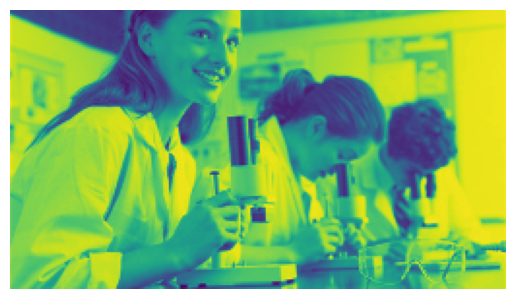

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Create a 10x10 "image" with random colors
# Shape: (Height, Width, Channels) where Channels are R, G, B
data = np.load("/data/dynamic29513-my-images-AB/screen/data/00008.npy")

# 2. Visualize using Matplotlib
plt.imshow(data)
plt.axis('off') # Hide the X and Y pixel coordinates
plt.show()

In [14]:
!ls /data

 dummy			        dynamic29513-my-images-AB
 dummy2			        dynamic29513-my-test
 dummy_data		        dynamic29513-two-test
 dynamic29513-3-5-Video-full    monkey_data
'dynamic29513-my-images copy'   my_data.zip
 dynamic29513-my-images-AA      my_dataset_with_meta
